# Machine Learning Classification with PyCaret

## 1. Import Required Libraries and Check Version

In [1]:
# Check PyCaret version
from pycaret.utils import version
version()

'3.2.0'

In [2]:
import pandas as pd
import os
from pycaret.classification import *

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Explore Datasets

In [3]:
# Load the ECFP fingerprint data
data_path = 'fp-gen/ecfp/HsDHODH-curated_ecfp_diam4_2048bits.csv'

# Check if file exists
if os.path.exists(data_path):
    print(f"✓ Found dataset: {data_path}")
    data = pd.read_csv(data_path)
    print(f"Dataset shape: {data.shape}")
else:
    print(f"⚠ Dataset not found: {data_path}")
    print("Please ensure the fingerprint generation has been completed")

✓ Found dataset: fp-gen/ecfp/HsDHODH-curated_ecfp_diam4_2048bits.csv
Dataset shape: (1792, 2050)


In [4]:
# Display basic information about the dataset
print("Dataset Info:")
print("=" * 50)
print(f"Number of rows: {data.shape[0]}")
print(f"Number of columns: {data.shape[1]}")
print(f"Columns: {list(data.columns[:5])}... (showing first 5)")

# Display first few rows
print("\nFirst 5 rows:")
display_cols = ['SMILES', 'Outcome'] + list(data.columns[2:7])  # First 5 fingerprint bits
print(data[display_cols].head())

Dataset Info:
Number of rows: 1792
Number of columns: 2050
Columns: ['SMILES', 'Outcome', '0', '1', '2']... (showing first 5)

First 5 rows:
                                              SMILES  Outcome  0  1  2  3  4
0  C=c1[nH]n(-c2ccccc2)c(=O)c1=Cc1ccc(-c2cccc(C(=...      0.0  0  0  0  0  0
1  CCC(=O)C(C#N)C(=O)Nc1ccc(-c2ccc(F)nc2)c(C(=O)O...      1.0  0  1  0  0  0
2      O=C1C(O)=C(Nc2cccc(C(F)(F)F)c2)C(=O)c2ccccc21      1.0  0  1  0  0  0
3  CCCn1c(CO)nn(-c2cc(OC(C)C(F)(F)F)c(C(=O)Nc3c(F...      1.0  0  1  0  0  0
4         COc1cccc(-c2cc(F)c(Nc3ncccc3C(=O)O)cc2F)c1      1.0  0  0  0  0  0


## 3. Data Preprocessing

In [5]:
# Prepare data for PyCaret
print("Preparing data for machine learning...")

# Remove SMILES column as it's not needed for ML (keep only Outcome and fingerprint bits)
if 'SMILES' in data.columns:
    ml_data = data.drop('SMILES', axis=1)
    print("✓ Removed SMILES column")
else:
    ml_data = data.copy()

print(f"Final dataset shape for ML: {ml_data.shape}")
print(f"Features: {ml_data.shape[1] - 1} fingerprint bits")
print(f"Target: Outcome")

Preparing data for machine learning...
✓ Removed SMILES column
Final dataset shape for ML: (1792, 2049)
Features: 2048 fingerprint bits
Target: Outcome


In [6]:
# Check data types and basic statistics
print("Data Types Summary:")
print(ml_data.dtypes.value_counts())

print(f"\nTarget variable unique values: {ml_data['Outcome'].unique()}")
print(f"Number of unique classes: {ml_data['Outcome'].nunique()}")

Data Types Summary:
int64      2048
float64       1
dtype: int64

Target variable unique values: [0. 1.]
Number of unique classes: 2


In [7]:
from sklearn.model_selection import train_test_split

# Stratified split of ml_data into train (70%) and test (30%) sets
train_data, test_data = train_test_split(
    ml_data,
    test_size=0.2,
    stratify=ml_data['Outcome'],
    random_state=143
)

print(f"Train set shape: {train_data.shape}")
print(f"Test set shape: {test_data.shape}")
print(f"Train Outcome distribution:\n{train_data['Outcome'].value_counts(normalize=True)}")
print(f"Test Outcome distribution:\n{test_data['Outcome'].value_counts(normalize=True)}")

Train set shape: (1433, 2049)
Test set shape: (359, 2049)
Train Outcome distribution:
1.0    0.597348
0.0    0.402652
Name: Outcome, dtype: float64
Test Outcome distribution:
1.0    0.598886
0.0    0.401114
Name: Outcome, dtype: float64


## 4. Pycaret Setup

In [8]:
# Setup PyCaret classification environment
print("Setting up PyCaret classification environment...")
print("This may take a moment...")

clf1 = setup(data=train_data, 
    target='Outcome', 
    session_id=143,
    remove_multicollinearity=True,
    fix_imbalance=True,
    fold_strategy='stratifiedkfold',
    experiment_custom_tags={'Project': 'H3D_HsDHODH', 'Type': 'Classification'},
    experiment_name='HsDHODH_ECFP_diam4_2048bits_multicollinearity_SMOTE',
    log_plots=True,  
    log_data=True,  
    log_profile=True,  
    train_size=0.8,
    use_gpu=False,  
    preprocess=True,
    fix_imbalance_method='smote',
    multicollinearity_threshold=0.90,
    data_split_stratify=True,
)

Setting up PyCaret classification environment...
This may take a moment...


,Description,Value
0,Session id,143
1,Target,Outcome
2,Target type,Binary
3,Original data shape,"(1433, 2049)"
4,Transformed data shape,"(1657, 1846)"
5,Transformed train set shape,"(1370, 1846)"
6,Transformed test set shape,"(287, 1846)"
7,Numeric features,2048
8,Preprocess,True
9,Imputation type,simple


## 5. Compare Multiple Models

In [9]:
# Compare different classification algorithms
print("Comparing multiple classification models...")
print("This will train and evaluate various algorithms using cross-validation")

best_models = compare_models(
    include=['lr', 'rf', 'et', 'xgboost', 'nb', 'svm', 'knn', 'dummy'],
    sort='Accuracy',
    n_select=10,  
    verbose=True
)

Comparing multiple classification models...
This will train and evaluate various algorithms using cross-validation


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.8726,0.9367,0.9155,0.8778,0.8954,0.7325,0.7360,1.2170
et,Extra Trees Classifier,0.8665,0.9386,0.9067,0.8755,0.8899,0.7203,0.7238,1.2630
lr,Logistic Regression,0.8657,0.9323,0.8907,0.8860,0.8874,0.7207,0.7233,1.3580
rf,Random Forest Classifier,0.8622,0.9362,0.9067,0.8689,0.8869,0.7105,0.7134,1.3180
knn,K Neighbors Classifier,0.8412,0.9160,0.8249,0.9018,0.8607,0.6768,0.6821,0.9010
svm,SVM - Linear Kernel,0.8395,0.0000,0.8848,0.8539,0.8670,0.6639,0.6705,0.9190
nb,Naive Bayes,0.7618,0.8132,0.7330,0.8491,0.7856,0.5209,0.5294,0.9080
dummy,Dummy Classifier,0.4023,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.9010


Available columns: ['Model', 'Accuracy', 'AUC', 'Recall', 'Prec.', 'F1', 'Kappa', 'MCC', 'TT (Sec)']
Plotting metrics: ['Accuracy', 'MCC', 'F1']


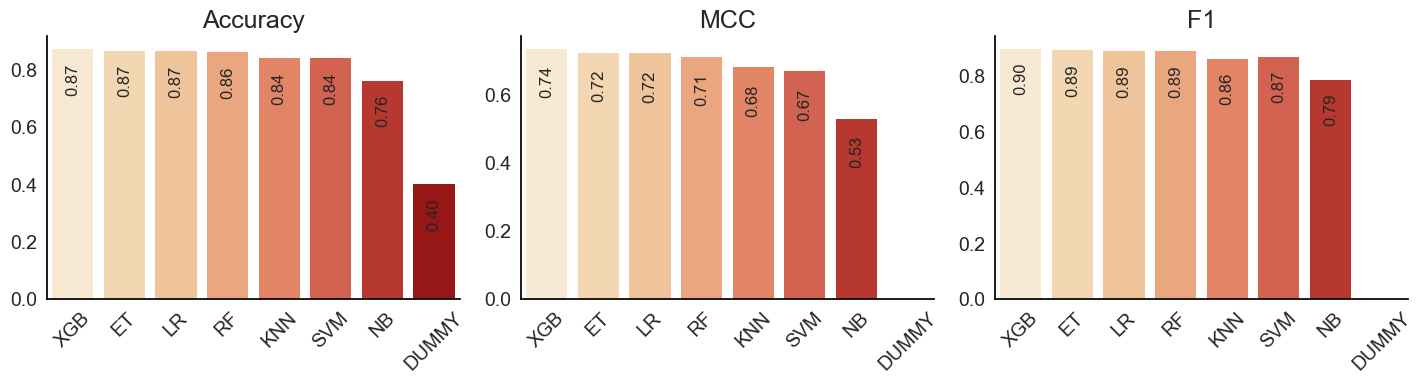

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pull the latest cross-validation metrics from PyCaret
metrics_df = pull().copy()

# Check available columns
print("Available columns:", metrics_df.columns.tolist())

# Select metrics that exist in the DataFrame
metrics_to_plot = ['Accuracy', 'MCC', 'F1']
available_metrics = [m for m in metrics_to_plot if m in metrics_df.columns]

if not available_metrics:
    print("Warning: None of the desired metrics found. Using default metrics.")
    # Use first 3 numeric columns as fallback
    numeric_cols = metrics_df.select_dtypes(include=[np.number]).columns.tolist()
    available_metrics = numeric_cols[:3] if len(numeric_cols) >= 3 else numeric_cols

print(f"Plotting metrics: {available_metrics}")
metrics_df = metrics_df[available_metrics]

# Map model acronyms to desired uppercase labels
mapping = {'et': 'ET', 'rf': 'RF', 'xgboost': 'XGB', 'lr': 'LR',
           'knn': 'KNN', 'svm': 'SVM', 'nb': 'NB', 'dummy': 'DUMMY'}

# Add Model column with mapped labels and preserve plotting order
metrics_df['Model'] = metrics_df.index.map(lambda x: mapping.get(x, x))
model_order = [mapping.get(x, x) for x in metrics_df.index]

# Melt for seaborn
metrics_long = metrics_df.melt(id_vars=['Model'], var_name='Metric', value_name='Score')
metrics_long['Model'] = pd.Categorical(metrics_long['Model'], categories=model_order, ordered=True)

# Plot
g = sns.FacetGrid(metrics_long, col='Metric', col_wrap=3, height=4, aspect=1.2, sharey=False)
g.map(sns.barplot, 'Model', 'Score', palette='OrRd', order=model_order)

# Set titles and style
for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_title(title, fontsize=18)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_facecolor('white')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')    
    for p in ax.patches:
        h = p.get_height()
        if h is not None and h > 0:
            ax.text(p.get_x() + p.get_width()/2., h - 0.05, f'{h:.2f}',
                    ha='center', va='top', fontsize=12, rotation=90)

plt.tight_layout()
plt.show()

## 6. Create Individual Models

In [11]:
# Create the best performing model (Random Forest as default)
print("Creating XGB model...")
xgb_model = create_model('xgboost')
print(f"XGB model shape - Features: {xgb_model.n_features_in_}, Classes: {xgb_model.n_classes_}")

Creating XGB model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8174,0.9061,0.8116,0.8750,0.8421,0.6263,0.6288
1,0.8783,0.9559,0.9130,0.8873,0.9000,0.7445,0.7450
2,0.9217,0.9556,0.9565,0.9167,0.9362,0.8352,0.8364
3,0.9043,0.9619,0.9130,0.9265,0.9197,0.8014,0.8016
4,0.8174,0.9030,0.8551,0.8429,0.8489,0.6182,0.6183
5,0.8696,0.9227,0.9118,0.8732,0.8921,0.7274,0.7285
6,0.9035,0.9581,0.9853,0.8701,0.9241,0.7930,0.8046
7,0.8509,0.9239,0.9412,0.8312,0.8828,0.6801,0.6901
8,0.8596,0.9150,0.9412,0.8421,0.8889,0.7000,0.7080


XGB model shape - Features: 1845, Classes: 2


In [12]:
# Create Extra Trees model
print("Creating Extra Trees model...")
et_model = create_model('et')
print(f"ET model shape - Features: {et_model.n_features_in_}, Classes: {et_model.n_classes_}")

Creating Extra Trees model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8087,0.8971,0.8261,0.8507,0.8382,0.6043,0.6047
1,0.8609,0.9401,0.9130,0.8630,0.8873,0.7059,0.7078
2,0.9217,0.9611,0.9710,0.9054,0.9371,0.8339,0.8375
3,0.8522,0.9494,0.8406,0.9062,0.8722,0.6975,0.7003
4,0.8522,0.9253,0.8841,0.8714,0.8777,0.6909,0.6910
5,0.8609,0.9348,0.8676,0.8939,0.8806,0.7140,0.7145
6,0.8860,0.9562,0.9706,0.8571,0.9103,0.7554,0.7664
7,0.8596,0.9298,0.9118,0.8611,0.8857,0.7043,0.7062
8,0.8596,0.9433,0.9559,0.8333,0.8904,0.6978,0.7106


ET model shape - Features: 1845, Classes: 2


In [13]:
# Create Random Forest model
print("Creating Random Forest model...")
rf_model = create_model('rf')
print(f"RF model shape - Features: {rf_model.n_features_in_}, Classes: {rf_model.n_classes_}")

Creating Random Forest model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.8973,0.8261,0.8382,0.8321,0.5848,0.5849
1,0.8696,0.9474,0.8986,0.8857,0.8921,0.7273,0.7274
2,0.9130,0.9658,0.9710,0.8933,0.9306,0.8148,0.8199
3,0.8609,0.9469,0.8841,0.8841,0.8841,0.7101,0.7101
4,0.8261,0.9179,0.8696,0.8451,0.8571,0.6350,0.6355
5,0.8696,0.9290,0.8824,0.8955,0.8889,0.7310,0.7311
6,0.8684,0.9519,0.9706,0.8354,0.8980,0.7157,0.7317
7,0.8421,0.9150,0.8971,0.8472,0.8714,0.6673,0.6691
8,0.8772,0.9436,0.9412,0.8649,0.9014,0.7394,0.7440


RF model shape - Features: 1845, Classes: 2


In [14]:
# Create Logistic Regression model
print("Creating Logistic Regression model...")
lr_model = create_model('lr')
print(f"LR model shape - Features: {lr_model.n_features_in_}, Classes: {len(lr_model.classes_)}")

Creating Logistic Regression model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.8878,0.7971,0.8594,0.8271,0.5907,0.5931
1,0.8783,0.9490,0.8986,0.8986,0.8986,0.7464,0.7464
2,0.9130,0.9669,0.9420,0.9155,0.9286,0.8175,0.8181
3,0.8783,0.9559,0.8551,0.9365,0.8939,0.7518,0.7561
4,0.8261,0.9086,0.8406,0.8657,0.8529,0.6403,0.6407
5,0.8522,0.9146,0.8529,0.8923,0.8722,0.6971,0.6981
6,0.8947,0.9447,0.9853,0.8590,0.9178,0.7734,0.7875
7,0.8333,0.9204,0.8824,0.8451,0.8633,0.6501,0.6511
8,0.8772,0.9236,0.9265,0.8750,0.9000,0.7412,0.7433


LR model shape - Features: 1845, Classes: 2


## 7. Tunning individual models

In [15]:
# Tune hyperparameters for the best model
print("Tuning XGB hyperparameters...")
tunned_xgb = tune_model(xgb_model, round=4, n_iter=20, search_library='optuna')
print(f"XGB model shape - Features: {tunned_xgb.n_features_in_}, Classes: {tunned_xgb.n_classes_}")

Tuning XGB hyperparameters...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8174,0.8825,0.8841,0.8243,0.8531,0.6125,0.6152
1,0.8261,0.9442,0.9275,0.8101,0.8649,0.6241,0.6354
2,0.8957,0.9647,0.9855,0.8608,0.9189,0.7744,0.7885
3,0.9130,0.9562,0.9710,0.8933,0.9306,0.8148,0.8199
4,0.8435,0.9011,0.9420,0.8228,0.8784,0.6617,0.6737
5,0.8609,0.9055,0.9265,0.8514,0.8873,0.7064,0.7107
6,0.8772,0.9658,1.0000,0.8293,0.9067,0.7317,0.7595
7,0.8246,0.9162,0.9412,0.8000,0.8649,0.6195,0.6363
8,0.8509,0.9210,0.9559,0.8228,0.8844,0.6778,0.6930


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
XGB model shape - Features: 1845, Classes: 2


In [16]:
# Tune hyperparameters for the best model
print("Tuning Extra Trees hyperparameters...")
tunned_et = tune_model(et_model, round=4, n_iter=20, search_library='optuna')
print(f"ET model shape - Features: {tunned_et.n_features_in_}, Classes: {tunned_et.n_classes_}")

Tuning Extra Trees hyperparameters...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7913,0.9011,0.7536,0.8814,0.8125,0.5804,0.5895
1,0.8609,0.9537,0.8696,0.8955,0.8824,0.7122,0.7127
2,0.8870,0.9660,0.9275,0.8889,0.9078,0.7619,0.7631
3,0.8435,0.9496,0.8261,0.9048,0.8636,0.6809,0.6847
4,0.8261,0.9042,0.8696,0.8451,0.8571,0.6350,0.6355
5,0.8522,0.9168,0.8824,0.8696,0.8759,0.6931,0.6933
6,0.8684,0.9428,0.9559,0.8442,0.8966,0.7177,0.7282
7,0.8421,0.9130,0.8824,0.8571,0.8696,0.6697,0.6701
8,0.8596,0.9252,0.8971,0.8714,0.8841,0.7064,0.7069


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
ET model shape - Features: 1845, Classes: 2


In [17]:
# Tune hyperparameters for the best model
print("Tuning Random Forest hyperparameters...")
tunned_rf = tune_model(rf_model, round=4, n_iter=20, search_library='optuna')
print(f"RF model shape - Features: {tunned_rf.n_features_in_}, Classes: {tunned_rf.n_classes_}")

Tuning Random Forest hyperparameters...


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
RF model shape - Features: 1845, Classes: 2


In [18]:
# Tune hyperparameters for the best model
print("Tuning Linear Regression hyperparameters...")
tunned_lr = tune_model(lr_model, round=4, n_iter=20, search_library='optuna')
print(f"LR model shape - Features: {tunned_lr.n_features_in_}, Classes: {len(tunned_lr.classes_)}")

Tuning Linear Regression hyperparameters...


,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,15:42:43
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.8922,0.7681,0.8833,0.8217,0.5965,0.6041
1,0.8783,0.9521,0.8841,0.9104,0.8971,0.7482,0.7487
2,0.9478,0.9745,0.9710,0.9437,0.9571,0.8905,0.8911
3,0.8522,0.9527,0.8406,0.9062,0.8722,0.6975,0.7003
4,0.8522,0.9127,0.8696,0.8824,0.8759,0.6931,0.6933
5,0.8522,0.9102,0.8676,0.8806,0.8741,0.6952,0.6953
6,0.9035,0.9441,0.9706,0.8800,0.9231,0.7945,0.8014
7,0.8333,0.9191,0.8824,0.8451,0.8633,0.6501,0.6511
8,0.8684,0.9169,0.8971,0.8841,0.8905,0.7257,0.7258


LR model shape - Features: 1845, Classes: 2


Metrics DataFrame (sorted by Accuracy):
         Accuracy      F1     MCC
lr         0.8656  0.8879  0.7222
et         0.8526  0.8770  0.6953
rf         0.8438  0.8712  0.6751
xgboost    0.8403  0.8774  0.6733

Available columns: ['Accuracy', 'F1', 'MCC']
Plotting metrics: ['Accuracy', 'MCC', 'F1']


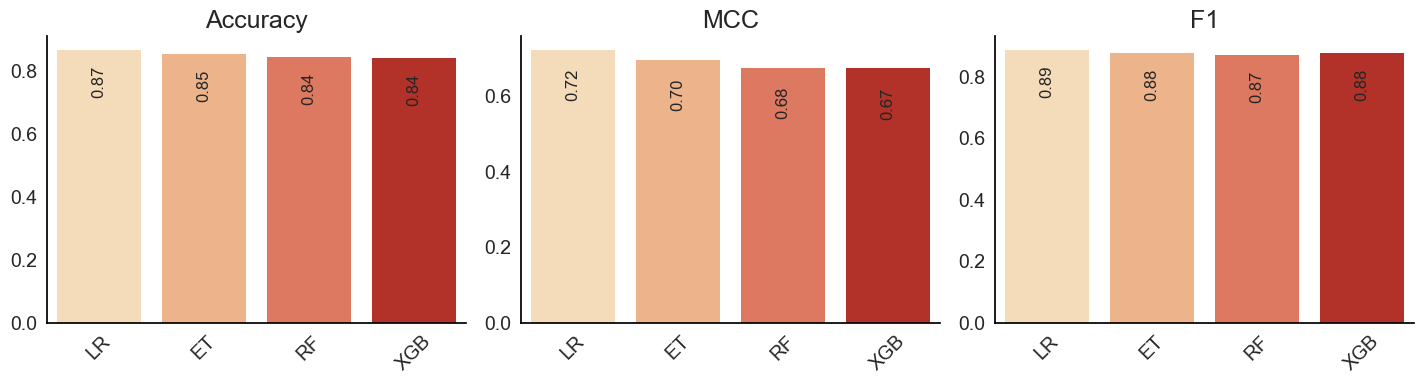

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create metrics data from the table
metrics_data = {
    'Accuracy': [0.8403, 0.8526, 0.8438, 0.8656],
    'F1': [0.8774, 0.8770, 0.8712, 0.8879],
    'MCC': [0.6733, 0.6953, 0.6751, 0.7222]
}

# Create DataFrame with model names as index
metrics_df = pd.DataFrame(metrics_data, index=['xgboost', 'et', 'rf', 'lr'])

# Sort by Accuracy in descending order
metrics_df = metrics_df.sort_values('Accuracy', ascending=False)

print("Metrics DataFrame (sorted by Accuracy):")
print(metrics_df)
print("\nAvailable columns:", metrics_df.columns.tolist())

# Select metrics to plot
metrics_to_plot = ['Accuracy', 'MCC', 'F1']
available_metrics = [m for m in metrics_to_plot if m in metrics_df.columns]

print(f"Plotting metrics: {available_metrics}")
metrics_df_plot = metrics_df[available_metrics]

# Map model acronyms to desired uppercase labels
mapping = {'et': 'ET', 'rf': 'RF', 'xgboost': 'XGB', 'lr': 'LR'}

# Add Model column with mapped labels and preserve plotting order
metrics_df_plot['Model'] = metrics_df_plot.index.map(lambda x: mapping.get(x, x))
model_order = [mapping.get(x, x) for x in metrics_df_plot.index]

# Melt for seaborn
metrics_long = metrics_df_plot.melt(id_vars=['Model'], var_name='Metric', value_name='Score')
metrics_long['Model'] = pd.Categorical(metrics_long['Model'], categories=model_order, ordered=True)

# Plot
g = sns.FacetGrid(metrics_long, col='Metric', col_wrap=3, height=4, aspect=1.2, sharey=False)
g.map(sns.barplot, 'Model', 'Score', palette='OrRd', order=model_order)

# Set titles and style
for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_title(title, fontsize=18)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_facecolor('white')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')    
    for p in ax.patches:
        h = p.get_height()
        if h is not None and h > 0:
            ax.text(p.get_x() + p.get_width()/2., h - 0.05, f'{h:.2f}',
                    ha='center', va='top', fontsize=12, rotation=90)

plt.tight_layout()
plt.show()


## 8. Generate Predictions 

In [20]:
# Generate predictions on test set
print("Generating predictions...")
predictions = predict_model(tunned_xgb, data=test_data)
print("Predictions shape:", predictions.shape)
print("\nFirst 10 predictions:")

Generating predictions...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.8747,0.9403,0.8884,0.9009,0.8946,0.7400,0.7401


Predictions shape: (359, 2051)

First 10 predictions:


In [21]:
# Generate predictions on test set
print("Generating predictions...")
predictions = predict_model(tunned_et, data=test_data)
print("Predictions shape:", predictions.shape)
print("\nFirst 10 predictions:")

Generating predictions...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8691,0.9363,0.9070,0.8784,0.8924,0.7253,0.7259


Predictions shape: (359, 2051)

First 10 predictions:


In [22]:
# Generate predictions on test set
print("Generating predictions...")
predictions = predict_model(tunned_rf, data=test_data)
print("Predictions shape:", predictions.shape)
print("\nFirst 10 predictions:")

Generating predictions...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.8747,0.9380,0.8977,0.8935,0.8956,0.7388,0.7388


Predictions shape: (359, 2051)

First 10 predictions:


In [23]:
# Generate predictions on test set
print("Generating predictions...")
predictions = predict_model(tunned_lr, data=test_data)
print("Predictions shape:", predictions.shape)
print("\nFirst 10 predictions:")

Generating predictions...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.8886,0.9421,0.8744,0.9353,0.9038,0.7718,0.7742


Predictions shape: (359, 2051)

First 10 predictions:


Metrics DataFrame (sorted by Accuracy):
         Accuracy      F1     MCC
xgboost    0.8747  0.8946  0.7401
rf         0.8747  0.8956  0.7388
et         0.8691  0.8924  0.7259
lr         0.8607  0.8798  0.7170

Available columns: ['Accuracy', 'F1', 'MCC']
Plotting metrics: ['Accuracy', 'MCC', 'F1']


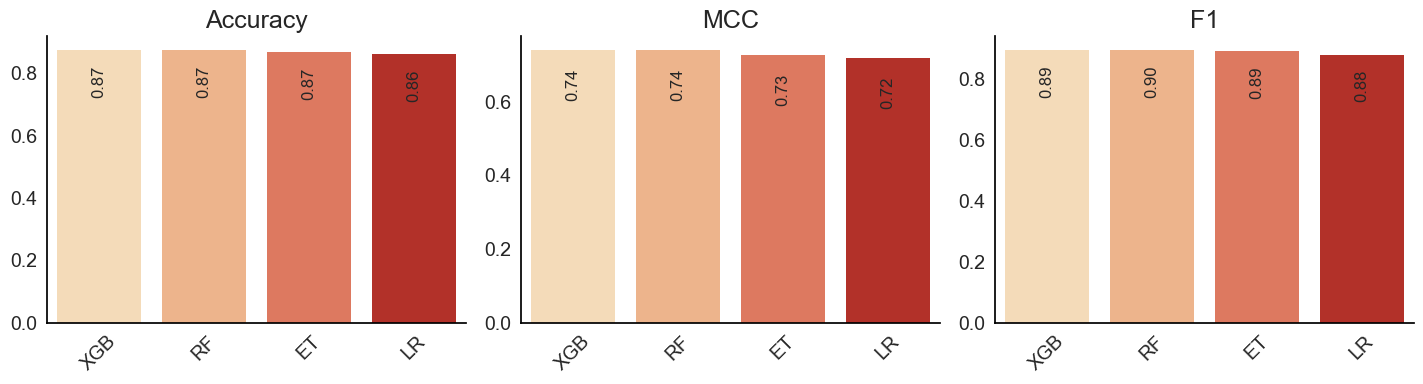

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create metrics data from the table
metrics_data = {
    'Accuracy': [0.8747, 0.8691, 0.8747, 0.8607],
    'F1': [0.8946, 0.8924, 0.8956, 0.8798],
    'MCC': [0.7401, 0.7259, 0.7388, 0.7170]
}

# Create DataFrame with model names as index
metrics_df = pd.DataFrame(metrics_data, index=['xgboost', 'et', 'rf', 'lr'])

# Sort by Accuracy in descending order
metrics_df = metrics_df.sort_values('Accuracy', ascending=False)

print("Metrics DataFrame (sorted by Accuracy):")
print(metrics_df)
print("\nAvailable columns:", metrics_df.columns.tolist())

# Select metrics to plot
metrics_to_plot = ['Accuracy', 'MCC', 'F1']
available_metrics = [m for m in metrics_to_plot if m in metrics_df.columns]

print(f"Plotting metrics: {available_metrics}")
metrics_df_plot = metrics_df[available_metrics]

# Map model acronyms to desired uppercase labels
mapping = {'et': 'ET', 'rf': 'RF', 'xgboost': 'XGB', 'lr': 'LR'}

# Add Model column with mapped labels and preserve plotting order
metrics_df_plot['Model'] = metrics_df_plot.index.map(lambda x: mapping.get(x, x))
model_order = [mapping.get(x, x) for x in metrics_df_plot.index]

# Melt for seaborn
metrics_long = metrics_df_plot.melt(id_vars=['Model'], var_name='Metric', value_name='Score')
metrics_long['Model'] = pd.Categorical(metrics_long['Model'], categories=model_order, ordered=True)

# Plot
g = sns.FacetGrid(metrics_long, col='Metric', col_wrap=3, height=4, aspect=1.2, sharey=False)
g.map(sns.barplot, 'Model', 'Score', palette='OrRd', order=model_order)

# Set titles and style
for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_title(title, fontsize=18)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_facecolor('white')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')    
    for p in ax.patches:
        h = p.get_height()
        if h is not None and h > 0:
            ax.text(p.get_x() + p.get_width()/2., h - 0.05, f'{h:.2f}',
                    ha='center', va='top', fontsize=12, rotation=90)

plt.tight_layout()
plt.show()


## 9. Evaluation and Intepretation

In [20]:
print("Evaluating tunned xgb model...")
evaluate_model(tunned_xgb)

Evaluating tunned xgb model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [21]:
print("Evaluating tunned ET model...")
evaluate_model(tunned_et)

Evaluating tunned ET model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

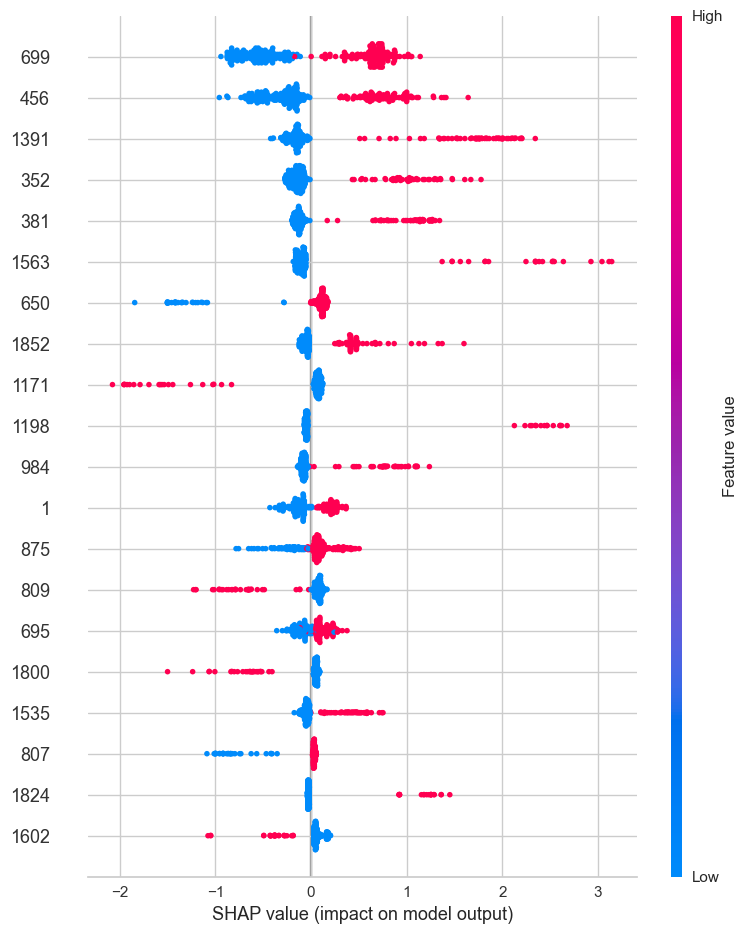

In [22]:
interpret_model(tunned_xgb)

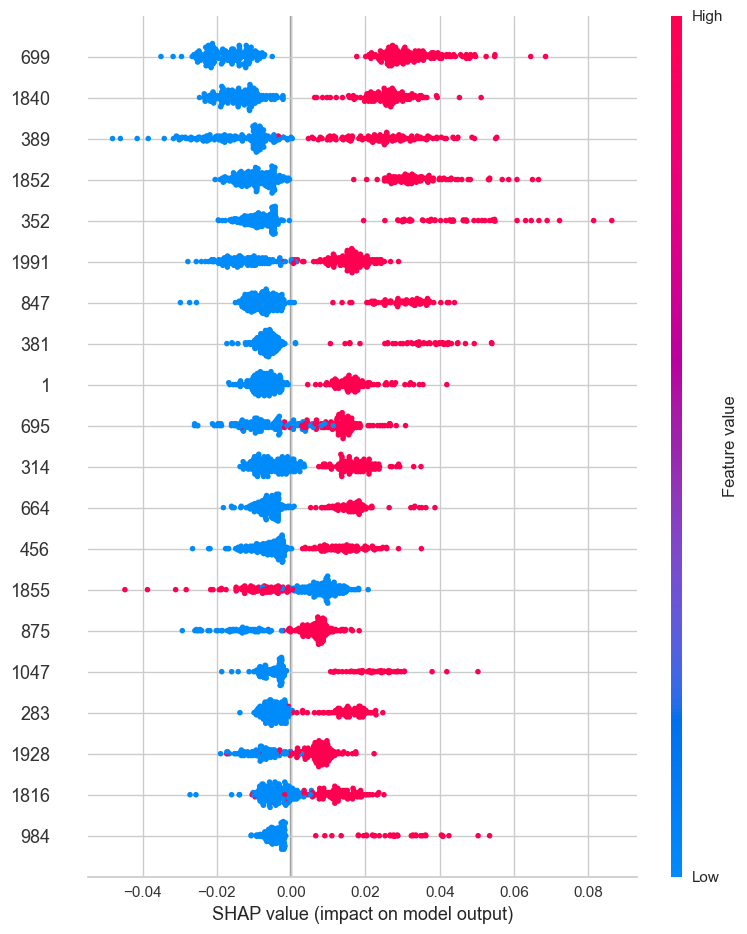

In [33]:
interpret_model(tunned_rf)

## 10. Save Models

In [35]:
# Save both final models
print("Saving final models...")

# Save XGBoost
try:
    save_model(tunned_xgb, 'models/HsDHODH_ECFP_diam4_1845bits_XGBoost_tunned')
    print("✓ XGBoost saved successfully!")
except Exception as e:
    print(f"⚠ Error saving XGBoost: {e}")

# Save Extra Trees
try:
    save_model(tunned_et, 'models/HsDHODH_ECFP_diam4_1845bits_ExtraTrees_tunned')
    print("✓ Extra Trees saved successfully!")
except Exception as e:
    print(f"⚠ Error saving Extra Trees: {e}")

print("\n✅ Models ready for use!")

# Save Linear Regression
try:
    save_model(tunned_lr, 'models/HsDHODH_ECFP_diam4_1845bits_LinearRegression_tunned')
    print("✓ Linear Regression saved successfully!")
except Exception as e:
    print(f"⚠ Error saving Linear Regression: {e}")

print("\n✅ Models ready for use!")

# Save Random Forest
try:
    save_model(tunned_rf, 'models/HsDHODH_ECFP_diam4_1845bits_RandomForest_tunned')
    print("✓ Random Forest saved successfully!")
except Exception as e:
    print(f"⚠ Error saving Random Forest: {e}")

print("\n✅ Models ready for use!")

Saving final models...
Transformation Pipeline and Model Successfully Saved
✓ XGBoost saved successfully!
Transformation Pipeline and Model Successfully Saved
✓ XGBoost saved successfully!
Transformation Pipeline and Model Successfully Saved
✓ Extra Trees saved successfully!

✅ Models ready for use!
Transformation Pipeline and Model Successfully Saved
✓ Extra Trees saved successfully!

✅ Models ready for use!
Transformation Pipeline and Model Successfully Saved
✓ Linear Regression saved successfully!

✅ Models ready for use!
Transformation Pipeline and Model Successfully Saved
✓ Random Forest saved successfully!

✅ Models ready for use!
✓ Linear Regression saved successfully!

✅ Models ready for use!
Transformation Pipeline and Model Successfully Saved
✓ Random Forest saved successfully!

✅ Models ready for use!


## Pipeline Summary
This notebook demonstrates a complete automated machine learning pipeline using PyCaret for molecular classification with multiple fingerprint types:

Key Steps:
1. Data Loading: Automatically load all fingerprint datasets (ECFP, FCFP, MACCS)
2. Data Exploration: Analyze each dataset's characteristics
3. Train-Test Split: Stratified split for each dataset
4. Model Comparison: Compare 8 classification algorithms per dataset
5. Model Training: Train and tune Random Forest and Extra Trees models
6. Model Evaluation: Cross-validation and test set evaluation
7. Model Saving: Save all trained models with descriptive names

Generated Outputs:
- Trained models for each fingerprint type (RF and ET)
- Complete experiment logs with MLflow
- Performance metrics for all models

- Test set predictions for each datasetThe pipeline processes multiple datasets automatically, making it easy to compare performance across different molecular fingerprint representations for QSAR analysis.

- Comprehensive results summary